# CLASSIFICATION  and SHAP TUTORIAL

Shap is a popular explainable AI package using which we can understand which features affect our model decisions and how they contribute to global predictions (feature importance) and local interpretations (decision path of classification of single data instance).

## Objective

This notebook aims to understand and use SHap package for this mobile classification dataset in order to understand what are the factors which influence a mobile to be in a particular price range . Which features of a mobile affects is price and whter they impact it positively or negatively. 

The notebook is divided into majorly:
* Feature Selection Using Ensemble trees Model (RandomForest & GradientBoosting)
* Shap Explainer for Trees
* Feature Selection & Tuning using SHAP Tune Package
* SVM Model
* Kernel Explainer for SVM 

## CONTENTS



# Import Libraries

In [1]:
!pip install shap

In [2]:
import pandas as pd
import os
import numpy as np 
######----------For Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(15,5)})
plt.style.use('fivethirtyeight')

######----------For Feature Selection and Modeling
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

######---------For SHAP/Model Explainations
import shap

# Load Data

In [3]:
DATAPATH = "../input/mobile-price-classification"

train= pd.read_csv(os.path.join(DATAPATH,"train.csv"))
#test= pd.read_csv(os.path.join(DATAPATH,"test.csv"))

In [4]:
train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


# Quick EDA

* We obeserve all variables are encoded .
* None of the columns have missing values 
* Target Column is "price_range"
* Target column having 4 different classes (0,1,2,3)
* Each of the class having 500 data points (balanced dataset)
* Total 20 features

In [5]:
#Check columns 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
# Unique Values in each column
train.nunique()

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
price_range         4
dtype: int64

In [7]:
# Data in each class we see it is balanced dataset
train.price_range.value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

# Detailed EDA

* Plotting binary class variables distribution

In [8]:
train[["battery_power","price_range"]].groupby(["price_range"]).mean()

,battery_power
price_range,
0,1116.902
1,1228.868
2,1228.320
3,1379.984


In [9]:
train['m_dep'].value_counts() # no mobile dep as value 0 

m_dep
0.1    320
0.2    213
0.8    208
0.5    205
0.7    200
0.3    199
0.9    195
0.6    186
0.4    168
1.0    106
Name: count, dtype: int64

# PairPlot

# Correlation Matrix

We can see from correlation matrix price_range most correlated with ram folllowed by px_Width,px_height,battery_power. We therefore can greatly reduce the dimensionality of the data.

invalid value encountered in less


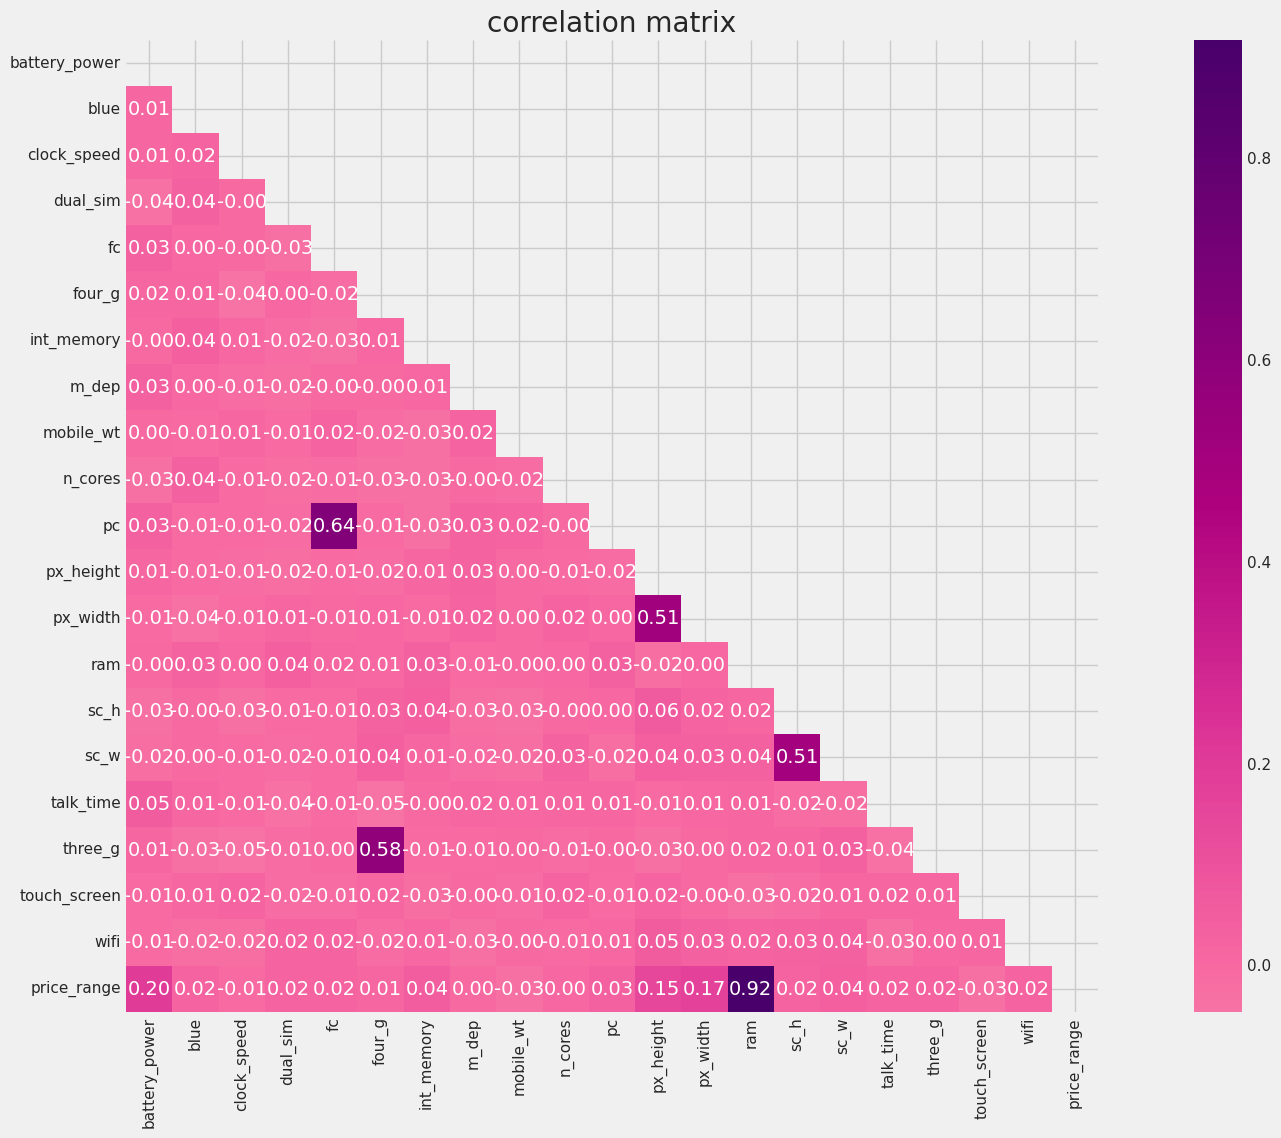

In [10]:
matrix = train.corr()
mask = np.triu(np.ones_like(matrix,dtype='bool'))

plt.figure(figsize=(22,12))
sns.heatmap(matrix,mask=mask,annot=True,center=0,fmt='.2f',square=True,cmap="RdPu").set(title="correlation matrix")
plt.show()

# Model Building : Ensemble Trees Model

* In this we will try to use trees ensemble model to look at feature importance as well as compare it with SHAP feature importance. 

In [11]:
#Seperating target
Xtrain = train.drop(columns='price_range',axis=1)
Ytrain = train.price_range

In [12]:
#Train Test Split

X_train,X_test,Y_train,Y_test = train_test_split(Xtrain,Ytrain,test_size=0.3,random_state=1200,stratify = Ytrain)
print(X_train.shape , X_test.shape)

(1400, 20) (600, 20)


## Random Forest

In [13]:
clf0= RandomForestClassifier(n_estimators=100,random_state=1200)
clf0.fit(X_train,Y_train)
std = np.std([tree.feature_importances_ for tree in clf0.estimators_], axis=0)
feature_importances = pd.Series(clf0.feature_importances_, index=X_train.columns)

print('Score of RF model on test split\n',clf0.score(X_test,Y_test))

Score of RF model on test split
 0.87


## Feature Importance Plot

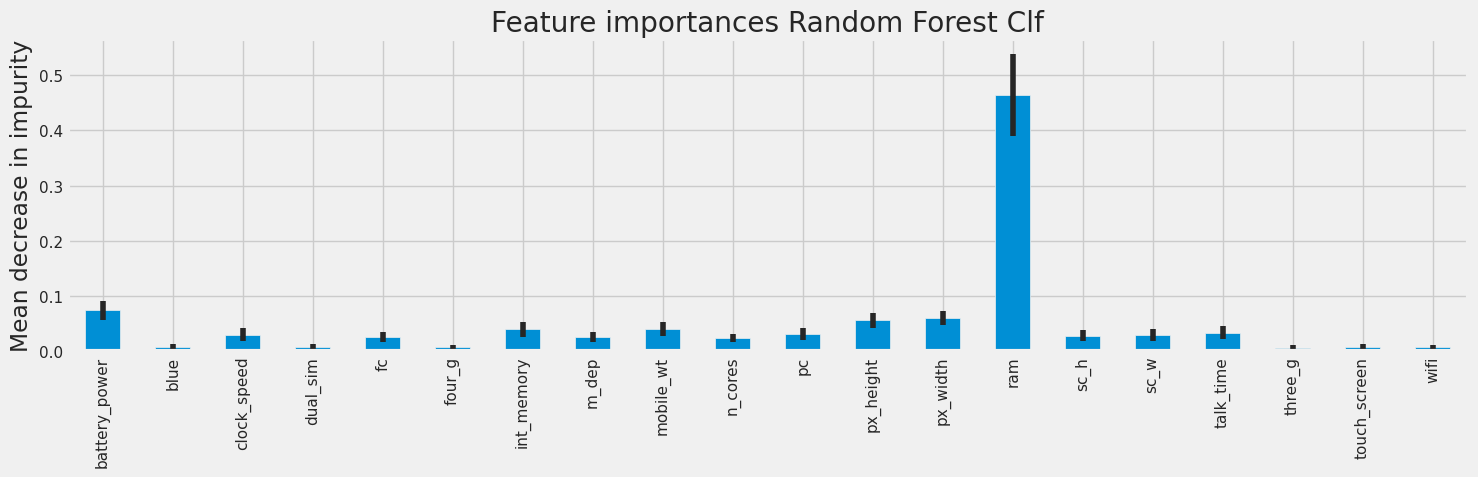

In [14]:
fig, ax = plt.subplots()
feature_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances Random Forest Clf")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

## GRadient Boosting Tree

In [15]:
clf= GradientBoostingClassifier(n_estimators=100,random_state=1200)
clf.fit(X_train,Y_train)

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)

print('Score of Gradient Boosting model on test split\n',clf.score(X_test,Y_test))



Score of Gradient Boosting model on test split
 0.9


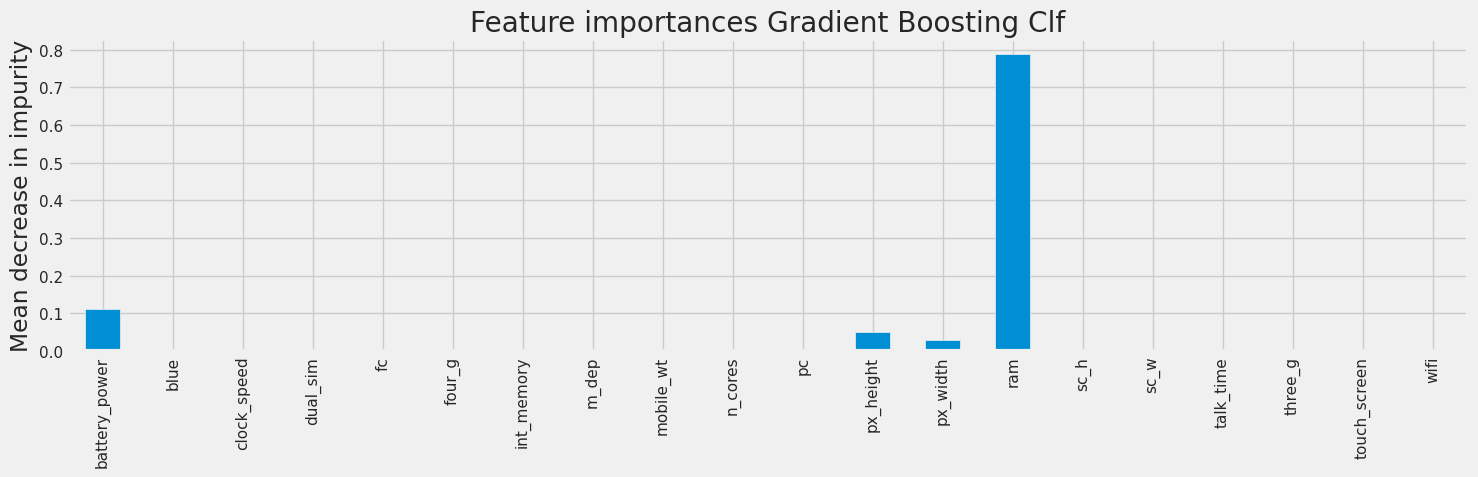

In [16]:
fig, ax = plt.subplots()
feature_importances.plot.bar(ax=ax)
ax.set_title("Feature importances Gradient Boosting Clf")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

## Feature Selection Using Feature Importance

In this we will use the feature importance returned by aboved tree models to select important features based on given threshold for feature importance and all features below that threshold are discarded.

Reference : https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection-using-selectfrommodel


In [17]:
#Feature selectiong for Random Forest Classifier Fitted Model
model0 = SelectFromModel(clf0, prefit=True) #we set prefit true since we are passing a fitted model as parameter
X_train_new = model0.transform(X_train)   #drops unimportant features

print('Shape of transformed Train set:',X_train_new.shape)
feature_names = X_train.columns[model0.get_support()]
print('Feature Names \n',feature_names)

Shape of transformed Train set: (1400, 4)
Feature Names 
 Index(['battery_power', 'px_height', 'px_width', 'ram'], dtype='object')


X has feature names, but SelectFromModel was fitted without feature names


In [18]:
X_test_new = X_test[['battery_power', 'px_height', 'px_width', 'ram']] #dropping unnecessary features
#clf0_modified.score(X_test,Y_test)

In [19]:
clf0_modified= RandomForestClassifier(n_estimators=70,random_state=1200)
clf0_modified.fit(X_train_new,Y_train)

RandomForestClassifier(n_estimators=70, random_state=1200)

In [20]:
clf0_modified.score(X_test_new,Y_test)

X has feature names, but RandomForestClassifier was fitted without feature names


0.9066666666666666

**After Feature Selection we can observe Model has shown an improvement by 4% . 
Earlier it was 87% now 90.66%**

In [21]:
#Feature selectiong for Gradient Boosting Classifier Fitted Model
model0 = SelectFromModel(clf, prefit=True) #we set prefit true since we are passing a fitted model as parameter
X_train_new = model0.transform(X_train)   #drops unimportant features

print('Shape of transformed Train set:',X_train_new.shape)
feature_names = X_train.columns[model0.get_support()]
print('Feature Names \n',feature_names)

Shape of transformed Train set: (1400, 3)
Feature Names 
 Index(['battery_power', 'px_height', 'ram'], dtype='object')


X has feature names, but SelectFromModel was fitted without feature names


In [22]:
X_test_new = X_test[['battery_power', 'px_height', 'ram']] #dropping unnecessary features
clf_modified= GradientBoostingClassifier(n_estimators=100,random_state=1200)
clf_modified.fit(X_train_new,Y_train)

GradientBoostingClassifier(random_state=1200)

In [23]:
clf_modified.score(X_test_new,Y_test)

X has feature names, but GradientBoostingClassifier was fitted without feature names


0.8666666666666667

Here performance of Gradient Boosting degraded after dropping all but 3 features.

# SHAP 
> 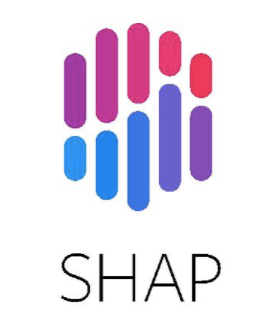

**SHAP (SHapley Additive exPlanations)** is a unified approach to explain the output of any machine learning model.

It combines game theory with machine learning models.
It has optimized functions for interpreting tree-based models and a model agnostic explainer function for interpreting any black-box model for which the predictions are known.
In summary, Shapley’s values calculate the importance of a feature by comparing what a model predicts with and without this feature. However, since the order in which a model sees the features can aﬀect its predictions, this is done in all possible ways, so that the features are compared fairly. This approach is inspired by game theory.
SHAP is used to explain an existing model. Taking a binary classification case built with a sklearn model. We train, tune and test our model. Then we can use our data and the model to create an additional SHAP model that explains our classification model.

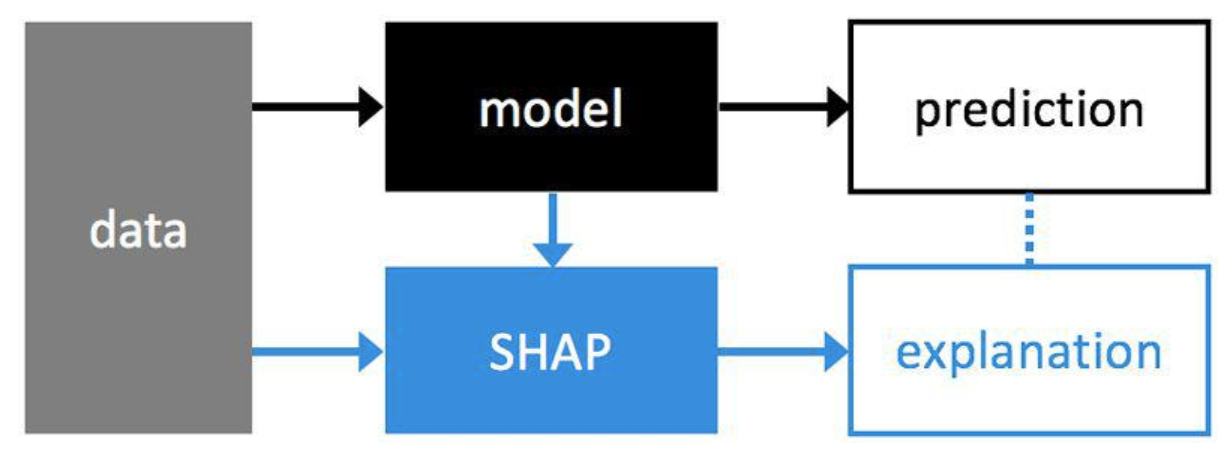

## SHAP Values using Explainer
We first create shap values using our model and data.

**shap_values** :  the average contribution of each feature to each prediction for each sample based on all possible features. It is a (n,m) n — samples, m — features matrix that represents the contribution of each feature to each sample.

* **Expected Values** : For our multiclass classification task shap explainer produces 4 expected values corresponding to each class probability. Here if we see each class expected value is 0.25 which is the probability of class label based on frequency of label only.
* Expected value is important as we shall see how the probability of belonging to a class is driven up or down from this base value to the final predicted value by the model at each step of feature value contribution .
   * *Note : For price range 0 = 500/2000 = 0.25, price range 1 = 500/2000 =0.25*
This is the probability obtained when no feature values are present then base probability is probability of belonging to the particular class label based on freq of class label in target variable.


* **Shap Values** :  The shap values of each class can be observerd below . If binary class then they are  *complementary* for binary classification.  

   * The *highest magnitude *contribution for* 'Price Range 0' class in below table is by the feature : 'ram' = 0.415436 , followed by 'px_height'=0.068004	 * all these features contribute positively towards the 'Price Range 0' class probability i.e. drives the probability for Price Range 0 class upwards.


> <span style="color:red">**IMPORTANT NOTE : Some Tree models such as xgboost,light gbm output logit (log-odds) instead probability so the shap expected values and shap values describe the logit odds instead of probability directly so caution should be taken when interpreting such models.**</span>

In [24]:
# creating an explainer for our model
explainer = shap.TreeExplainer(clf0) # we only need to pass our  fitted model to tree explainer. 
                                    #No background dataset in 'data' argument required for tree models as it
                                    #is automatically received through the model tree object.

# finding out the shap values using the explainer
shap_values = explainer.shap_values(X_train)

# Expected/Base/Reference value = the value that would be predicted if we didn’t know any features of the current output”
print('Expected Value:', explainer.expected_value)


Expected Value: [0.24953571 0.24869286 0.25193571 0.24983571]


In [25]:
# Shap Values for class =0 that is  class
print("Shap Values for 'Prince Range 0' class")
pd.DataFrame(shap_values[0],columns=X_train.columns).head()

Shap Values for 'Prince Range 0' class


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.047310,0.001503,0.00456,0.005277,0.012542,0.007559,0.035605,0.008697,0.022106,0.004805,0.022504,0.068004,-0.030740,0.415436,0.007838,0.016771,0.008736,0.002750,0.010068,0.003752
1,0.027309,0.000360,-0.00649,0.000063,-0.000872,-0.003318,-0.002464,-0.001940,-0.001982,-0.006232,-0.002729,-0.025288,-0.011131,-0.152415,-0.002823,-0.005966,-0.003164,-0.000518,0.000686,-0.000622
2,-0.071411,0.002442,0.00655,0.000959,0.003406,0.001053,0.008389,0.017879,0.009446,0.009259,0.025681,0.017829,0.052693,0.449161,0.014128,0.003087,0.012293,0.005197,-0.000235,0.002660
3,0.004268,-0.002006,-0.00852,-0.000534,-0.011324,-0.001934,-0.001493,0.000824,-0.009111,0.001364,-0.006909,0.004961,0.012840,-0.210935,-0.004152,-0.010896,-0.000127,0.000031,-0.002920,-0.002961
4,0.045075,0.004075,0.00128,0.001288,-0.003285,0.001116,0.016035,0.001917,-0.004259,0.006811,0.006582,0.041754,0.043127,0.473368,-0.004162,0.010397,-0.013278,-0.000023,0.003695,-0.001050


In [26]:
# Shap Values for class =1 that is  class
print("Shap Values for 'Prince Range 3' class")
pd.DataFrame(shap_values[3],columns=X_train.columns).head()

Shap Values for 'Prince Range 3' class


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,0.031844,-0.003436,-0.000301,-0.000638,-0.003896,-0.001316,-0.011832,-0.002692,-0.007928,-0.000990,-0.001864,-0.017450,0.027500,-0.257642,0.003261,0.003339,-0.005049,-0.000642,0.000332,-0.000435
1,-0.028511,0.002053,-0.001102,-0.003941,-0.001315,0.000796,0.004386,-0.001465,-0.003428,-0.005494,-0.005488,0.012820,-0.013176,-0.181783,0.005886,0.000406,0.000269,-0.000400,-0.000873,0.000525
2,0.035062,-0.001249,0.001168,0.000813,-0.003194,-0.003406,-0.000978,0.001814,-0.004843,0.001568,0.002773,0.000419,-0.018993,-0.245222,-0.001754,-0.000108,-0.004677,0.000685,-0.000570,0.000857
3,-0.024394,-0.007436,-0.000530,-0.003242,-0.002875,0.000577,-0.006220,-0.013998,0.022240,-0.001465,0.005304,-0.024551,-0.047621,-0.054056,-0.004023,-0.000114,-0.002150,-0.000868,-0.002910,-0.001505
4,-0.019490,0.001426,-0.000368,-0.003093,0.000062,0.001056,-0.005171,-0.001106,0.007795,-0.000785,-0.003915,-0.015259,-0.023698,-0.168570,-0.001324,-0.006420,0.000416,-0.000543,-0.000700,-0.000150


## SHAP Force Plot

These help us visualise each feature and how they force or drive the predictions and in which direction for each class. By default 'RED' drives up probability to higher and blue drives down the prob from base value.

* Force Plot can be for a single instance or data (local interpretations)
* Force plot for all data points

## FORCE plot for Single Data Point

Here we draw force plot for class 0 for first observation as 0th iloc. We see can below see that first observation has class 0 only so let's us understand how the prob of first observation is affected from all the features and what is the final prob  model predict for belonging to class 0.

In [27]:
X_train.iloc[0], 

(battery_power    1763.0
 blue                0.0
 clock_speed         0.5
 dual_sim            1.0
 fc                 12.0
 four_g              0.0
 int_memory         10.0
 m_dep               0.2
 mobile_wt         184.0
 n_cores             3.0
 pc                 19.0
 px_height         238.0
 px_width         1893.0
 ram               792.0
 sc_h               17.0
 sc_w               12.0
 talk_time          13.0
 three_g             1.0
 touch_screen        0.0
 wifi                1.0
 Name: 1383, dtype: float64,)

In [28]:
Y_train.iloc[0]  #the  observation has prica range of class 0

0

In [29]:
#Force Plot for a single observation for a single class 0
shap.initjs()
shap.force_plot(explainer.expected_value[0],
shap_values[0][0,:], X_train.iloc[0])

* Observe ram , px_height all have  low values which drives up the prob of belonging to class 0 that is lower price range. 
* Battery pwoer and px_width has larger values which drives down the prob. of belonging to class0 since large values of these features means prob of class 3 is higher so it is in tune with it. THe resultant final predicted prob of model is 0.83 prob of belonging to class 0

In [30]:
#Force Plot for a single observation for a single class 3
shap.initjs()
shap.force_plot(explainer.expected_value[3],
shap_values[3][0,:], X_train.iloc[0,:])

* Here we see force plot for same observation now wrt to prob of class3 price range. As we can see the features have reversed the red features for class 0 has become blue features in class 3 that is working as opposite. 
* The battery power and px_widht drives up the prob of belonging to class 3 but all other features severely drives down the prob making resultant pron as 0.0

In [31]:
#Force Plot for a single observation for a single class 2
shap.initjs()
shap.force_plot(explainer.expected_value[1],
shap_values[1][0,:], X_train.iloc[0,:])

In [32]:
from IPython.display import display

# Initialize SHAP visualizations
shap.initjs()

# Generate force plots for all classes (0, 1, 2, 3)
for class_idx in range(4): 
    print(f"Force Plot for Class {class_idx}")
    
    # Create a SHAP force plot for the first observation in X_train
    force_plot = shap.force_plot(
        explainer.expected_value[class_idx],        # Expected value (baseline prediction) for the class
        shap_values[class_idx][0, :],               # SHAP values for the first observation
        X_train.iloc[0, :]                          # Features of the first observation in X_train
    )
    
    # Display the force plot
    display(force_plot)


Force Plot for Class 0


Force Plot for Class 1


Force Plot for Class 2


Force Plot for Class 3


In [33]:
from IPython.display import display

# Initialize SHAP visualizations
shap.initjs()

# Generate force plots for all classes (0, 1, 2, 3) for the second sample (X_train.iloc[1])
for class_idx in range(4): 
    print(f"Force Plot for Class {class_idx} (Sample 1)")

    # Create a SHAP force plot for the second observation in X_train (index 1)
    force_plot = shap.force_plot(
        explainer.expected_value[class_idx],        # Expected value (baseline prediction) for the class
        shap_values[class_idx][1, :],               # SHAP values for the second observation
        X_train.iloc[1, :]                          # Features of the second observation in X_train
    )
    
    # Display the force plot
    display(force_plot)


Force Plot for Class 0 (Sample 1)


Force Plot for Class 1 (Sample 1)


Force Plot for Class 2 (Sample 1)


Force Plot for Class 3 (Sample 1)


In [34]:
from IPython.display import display

# Initialize SHAP visualizations
shap.initjs()

# Generate force plots for all classes (0, 1, 2, 3) for the first 10 samples
for sample_idx in range(10):  # Loop through the first 10 samples
    print(f"Force Plots for Sample {sample_idx}")
    
    # Generate force plots for each class (0, 1, 2, 3) for the current sample
    for class_idx in range(4):  # Assuming there are 4 classes: 0, 1, 2, and 3
        # Create a SHAP force plot for the current sample and class
        force_plot = shap.force_plot(
            explainer.expected_value[class_idx],        # Expected value (baseline prediction) for the class
            shap_values[class_idx][sample_idx, :],      # SHAP values for the current sample
            X_train.iloc[sample_idx, :]                 # Features of the current sample
        )
        
        # Display the force plot
        display(force_plot)


Force Plots for Sample 0


Force Plots for Sample 1


Force Plots for Sample 2


Force Plots for Sample 3


Force Plots for Sample 4


Force Plots for Sample 5


Force Plots for Sample 6


Force Plots for Sample 7


Force Plots for Sample 8


Force Plots for Sample 9


# SHAP Summary Plot

* The summary plot gives a global picture and similar to feature importance plot of tress . Here how each feature impacts the model for each class is shown.
* As shown in below ram , battery _power,px_widht ,px_height . we can see we got same features as important in trees model .

    * Summary for Single Class -  A summary plot for single class gives us densit  
    * Summary plot for all classes

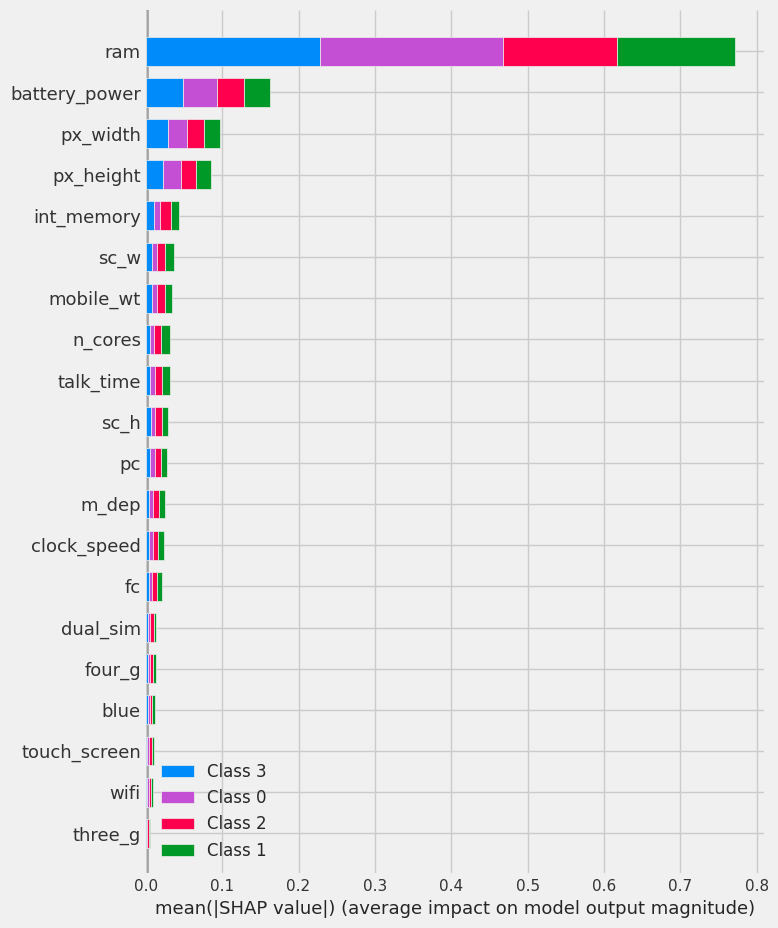

In [35]:
shap.initjs()
shap.summary_plot(shap_values, X_test)

**Summary Plot for Single Class**

Red means low feature value and blue means high feature value.  As we can see low values of ram drives up the prob of belonging to class 0 .Similarly low values of battery power,px_width,px_height drives up the prob of belonging to class 0. Now if you observe class 3 summary density plot you will see exact opposite of class 0 i.e. low values of ram drives down the prob of belonging to class 3 the higher price range which is logical conclusion . 

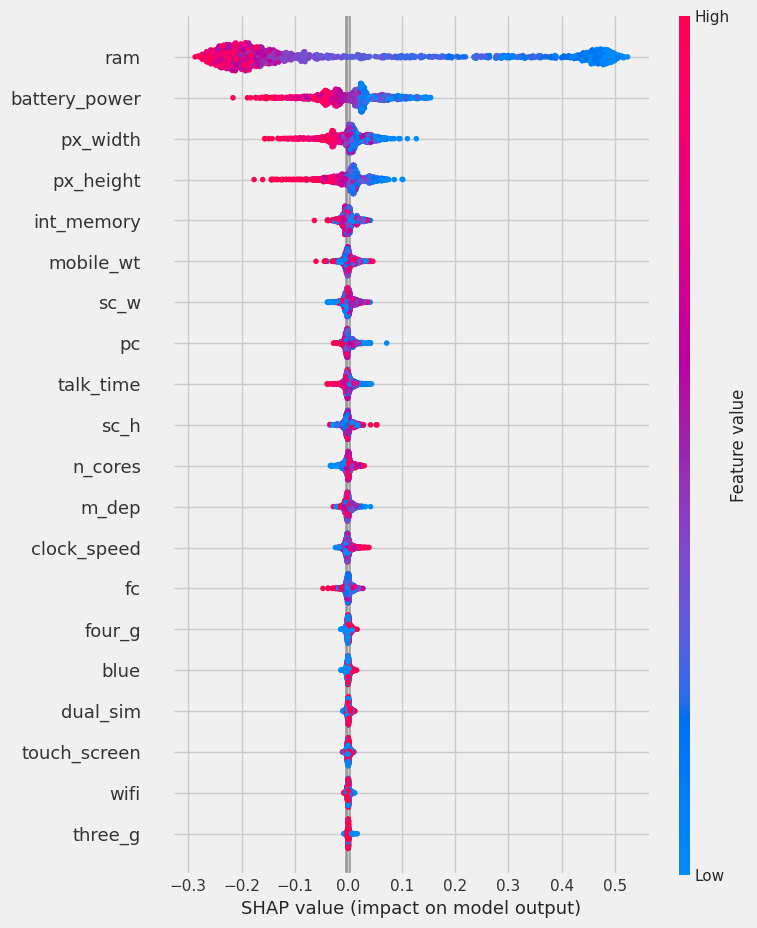

In [36]:
shap.initjs()
shap.summary_plot(shap_values[0], X_train)

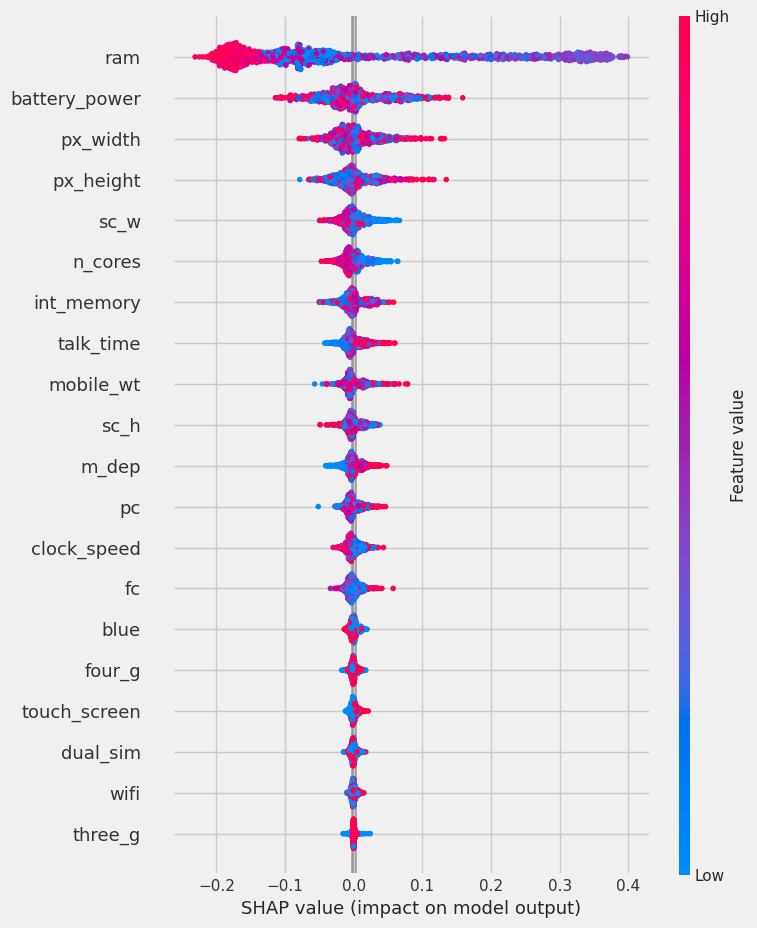

In [37]:
shap.initjs()
shap.summary_plot(shap_values[1], X_train)

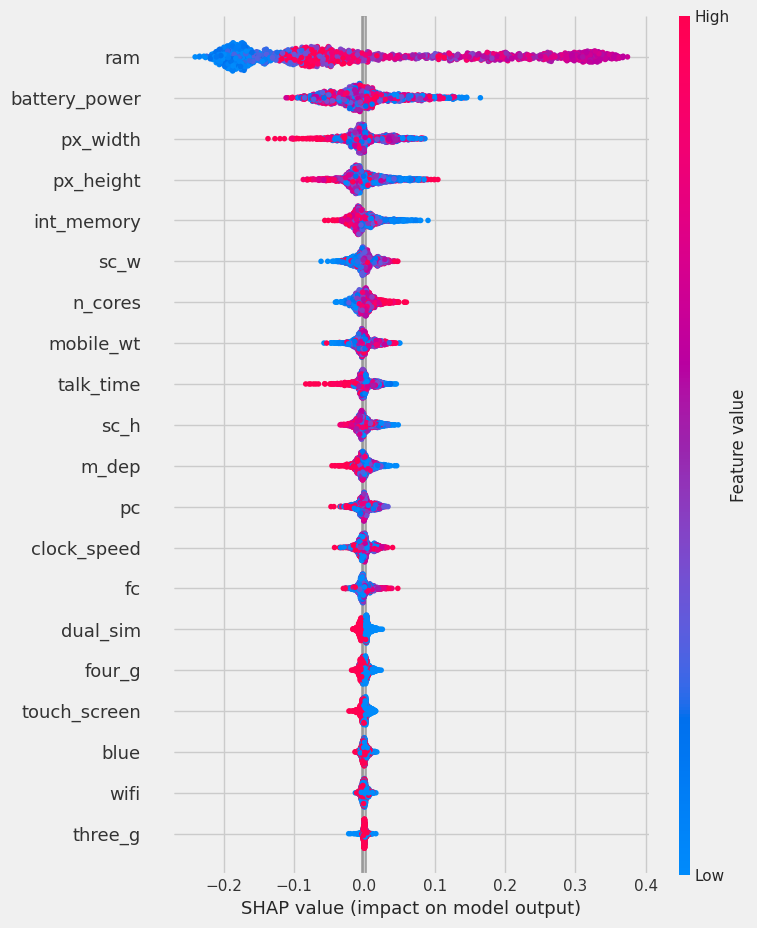

In [38]:
shap.initjs()
shap.summary_plot(shap_values[2], X_train)

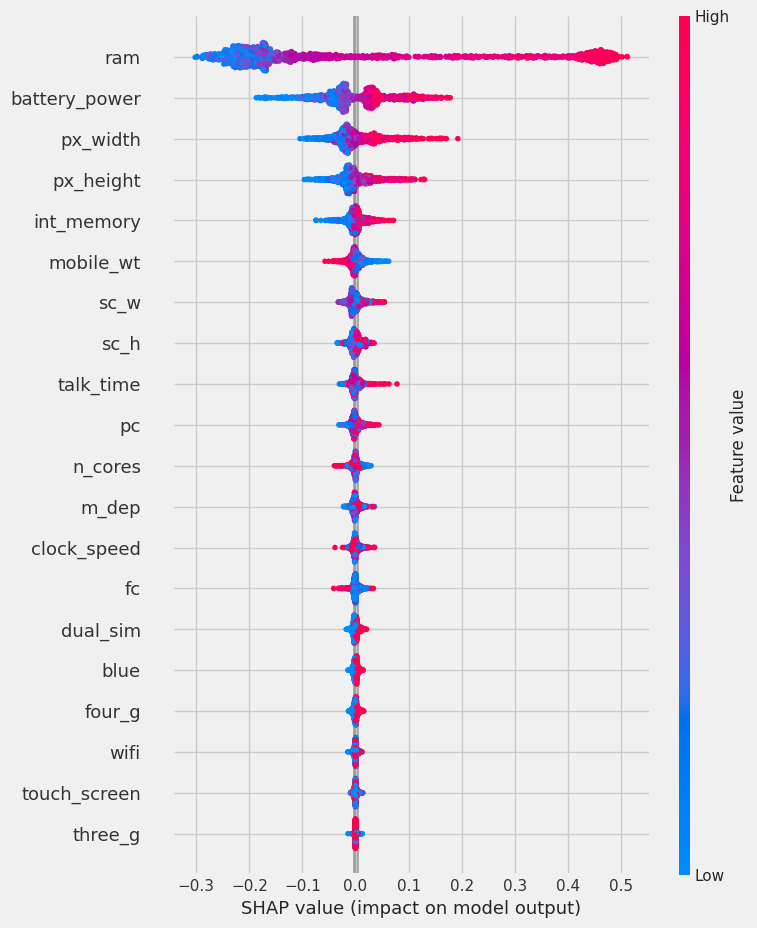

In [39]:
shap.initjs()
shap.summary_plot(shap_values[3], X_train)

Thus for all the above summary plot we can observe that for class 1 and class 2 the feature values overlap and misclassifications can occur more between these.

# SHAP Values for Test Set

In [40]:
# creating an explainer for our model
explainer = shap.TreeExplainer(clf0)

# finding out the shap values using the explainer
shap_values_test = explainer.shap_values(X_test)

In [41]:
y_pred=clf0.predict(X_test)
misclassified=Y_test!=y_pred
sum(misclassified) #total misclassified test observations

78

In [42]:
pred_true_tbl=pd.DataFrame({'True':Y_test,'Pred':y_pred,'Misclassified':misclassified})
display(pred_true_tbl[pred_true_tbl.Misclassified==True])
print(np.where(pred_true_tbl.Misclassified==True))  # Index location of misclassified predictions

,True,Pred,Misclassified
24,1,2,True
1516,1,2,True
292,2,1,True
1013,2,1,True
175,2,1,True
...,...,...,...
1606,1,2,True
1620,2,3,True
751,1,0,True
1473,1,0,True


(array([  3,   4,  11,  20,  24,  26,  32,  56,  60,  78,  88,  91, 100,
       109, 117, 124, 128, 139, 141, 165, 168, 172, 181, 210, 216, 235,
       239, 242, 256, 259, 263, 280, 285, 288, 293, 302, 307, 309, 330,
       334, 336, 342, 359, 385, 400, 405, 409, 412, 420, 422, 426, 430,
       440, 451, 455, 474, 475, 481, 484, 489, 494, 498, 512, 514, 527,
       534, 540, 546, 550, 551, 556, 557, 562, 567, 570, 577, 583, 588]),)


> # THANK YOU!! PLEASE HIT UPVOTE IF YOU LIKED THIS NOTEBOOK!!